# Masks
We can create a boolean array based on a condition and mask the pixels (hide, show or modify them) based on whether is truthy or falsy

Mask type: bool


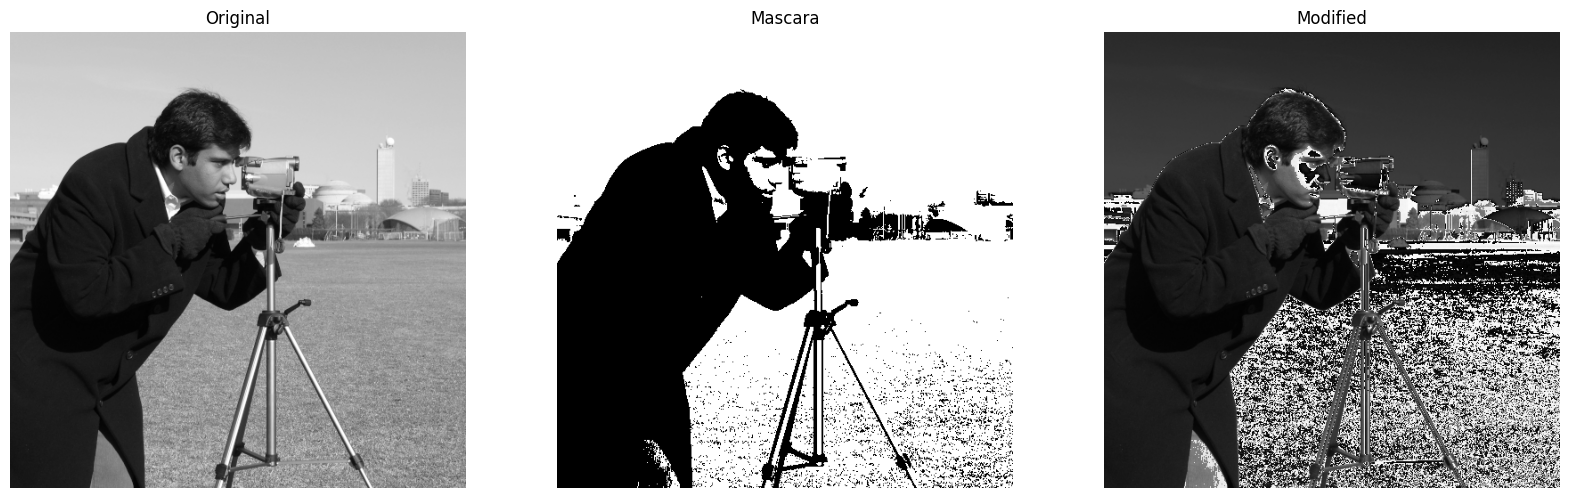

In [17]:
from skimage import data
import numpy as np
import matplotlib.pyplot as plt

img_camera = data.camera()

#A pixel on mask is true iff is greater than the mean
mean_mask = img_camera > np.mean(img_camera)

img_modified = img_camera.copy()

#Boolean indexing, only affects on true values
img_modified[mean_mask] += 100

print(f"Mask type: {mean_mask.dtype}")

fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20,20))
ax1.set_title("Original")
ax1.axis("off")
ax1.imshow(img_camera, cmap="gray")

ax2.set_title("Mascara")
ax2.axis("off")
ax2.imshow(mean_mask, cmap="gray")

ax3.set_title("Modified")
ax3.axis("off")
ax3.imshow(img_modified, cmap="gray")
plt.show()

We can also mask on shapes

nrows: 512, ncols: 512
Center row: 256.0, Center col: 256.0
[[131072. 130561. 130052. ... 129545. 130052. 130561.]
 [130561. 130050. 129541. ... 129034. 129541. 130050.]
 [130052. 129541. 129032. ... 128525. 129032. 129541.]
 ...
 [129545. 129034. 128525. ... 128018. 128525. 129034.]
 [130052. 129541. 129032. ... 128525. 129032. 129541.]
 [130561. 130050. 129541. ... 129034. 129541. 130050.]]


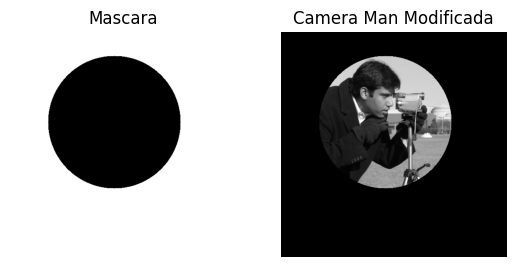

In [ ]:
img_camera = data.camera()

nrows, ncols = img_camera.shape
print(f"nrows: {nrows}, ncols: {ncols}")

# an array of dim (height, 1) and (1, witdh)
rows, cols = np.ogrid[:nrows, :ncols]
#print(f"Rows: {rows}, Cols: {cols}")


# Radious mask with displacement
centerRow = (nrows / 2) + 50
centerCol = (ncols / 2) + 20
print(f"Center row: {centerRow}, Center col: {centerCol}")

mask_outside_disk = (rows - centerRow)**2 + (cols - centerCol)**2 > 150**2
print((rows - centerRow)**2 + (cols - centerCol)**2)
# Seteamos en 0 a todos estos pixeles
img_camera[mask_outside_disk] = 0

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.set_title("Mascara")
ax1.axis("off")
ax1.imshow(mask_outside_disk, cmap="gray")

ax2.set_title("Camera Man Modificada")
ax2.axis("off")
ax2.imshow(img_camera, cmap="gray")
plt.show()